In [12]:
from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    while queue:
        node = queue.popleft()
        if node not in visited:
            print(node, end=" ")
            visited.add(node)
            queue.extend(graph[node])

def dfs(graph, node, visited=set()):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)
        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

print("BFS:")
bfs(graph, 'A')

print("\nDFS:")
dfs(graph, 'A')

BFS:
A B C D E F 
DFS:
A B D E C F 

Running for size: 1000
Running for size: 20000
Running for size: 50000
Running for size: 100000
Running for size: 200000
     Size  BFS Time  DFS Time
0    1000  0.000392  0.000319
1   20000  0.011768  0.011286
2   50000  0.023671  0.017451
3  100000  0.058576  0.050784
4  200000  0.095200  0.088164


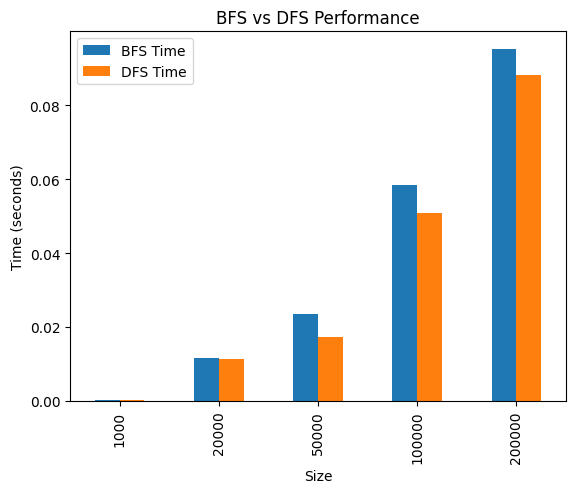

In [13]:
import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# BFS
def bfs(graph, start, goal):
    visited = set()
    queue = deque([start])
    start_time = time.time()

    while queue:
        node = queue.popleft()
        if node == goal:
            return time.time() - start_time
        if node not in visited:
            visited.add(node)
            queue.extend(graph.get(node, []))

    return time.time() - start_time


# DFS (ITERATIVE - FIXED)
def dfs(graph, start, goal):
    visited = set()
    stack = [start]
    start_time = time.time()

    while stack:
        node = stack.pop()
        if node == goal:
            return time.time() - start_time
        if node not in visited:
            visited.add(node)
            stack.extend(graph.get(node, []))

    return time.time() - start_time


sizes = [1000, 20000, 50000, 100000, 200000]

results = []

for size in sizes:
    print(f"Running for size: {size}")

    data = random.sample(range(size * 10), size)

    graph = {}
    for i in range(len(data) - 1):
        graph[data[i]] = [data[i + 1]]

    start = data[0]
    goal = data[len(data) - 220]

    bfs_time = bfs(graph, start, goal)
    dfs_time = dfs(graph, start, goal)

    results.append([size, bfs_time, dfs_time])


df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])
print(df)

# Plot
df.plot(x="Size", y=["BFS Time", "DFS Time"], kind="bar")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Performance")
plt.show()

In [14]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def shortest_path(start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                queue.append(path + [neighbor])

print("Shortest Path:", shortest_path("Islamabad", "Karachi"))

Shortest Path: ['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']
